In [ ]:
# Cài đặt các thư viện cần thiết
!pip install ultralytics

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from ultralytics import YOLO
import cv2
import os
import yaml
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

# Tắt GPU, chạy trên CPU
#tf.config.set_visible_devices([], 'GPU')  # Chỉ dùng CPU

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- STEP 1 ---
# Đường dẫn dữ liệu YOLOv8
dataset_path = "/content/drive/MyDrive/DeepLearning/dataset"
yaml_path = os.path.join(dataset_path, "data.yaml")

# Đọc file data.yaml
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)
    classes = data.get("names", [])
NUM_CLASSES = len(classes)
print(f"✅ Step 1: Problem Understanding - Số lớp: {NUM_CLASSES}, Danh sách lớp: {classes}")


✅ Step 1: Problem Understanding - Số lớp: 7, Danh sách lớp: ['Cam con lai', 'Cam dung va do', 'Cam nguoc chieu', 'Cam re', 'Gioi han toc do', 'Hieu lenh', 'Nguy hiem']


In [ ]:
# --- STEP 2: DATA UNDERSTANDING ---
def check_data(split):
    img_dir = os.path.join(dataset_path, split, "images")
    label_dir = os.path.join(dataset_path, split, "labels")
    img_count = len(os.listdir(img_dir))
    label_count = len(os.listdir(label_dir))
    print(f"📂 {split}: {img_count} ảnh, {label_count} nhãn")
    return img_count, label_count

print("\n✅ Step 2: Data Understanding")
for split in ["train", "valid", "test"]:
    check_data(split)

# Kiểm tra phân bố lớp
def analyze_labels(split):
    label_dir = os.path.join(dataset_path, split, "labels")
    label_files = os.listdir(label_dir)
    class_counts = np.zeros(NUM_CLASSES)
    for label_file in label_files:
        label_path = os.path.join(label_dir, label_file)
        with open(label_path, "r") as f:
            lines = f.readlines()
            if lines:
                class_id = int(lines[0].split()[0])
                class_counts[class_id] += 1
    return class_counts

train_counts = analyze_labels("train")
print(f"   - Phân bố lớp trong train: {train_counts}")


✅ Step 2: Data Understanding
📂 train: 6390 ảnh, 6390 nhãn
📂 valid: 433 ảnh, 433 nhãn
📂 test: 317 ảnh, 317 nhãn
   - Phân bố lớp trong train: [        691        1508         762         536         297         158        2097]


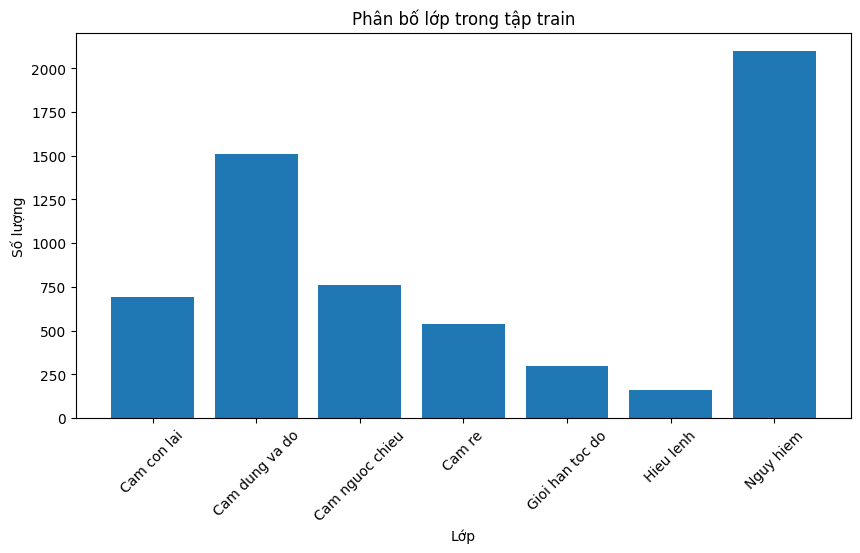

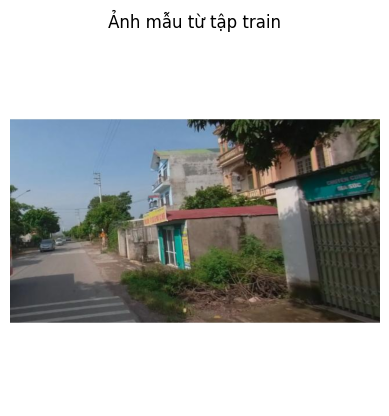

In [ ]:
# --- STEP 3: FEATURE UNDERSTANDING (EDA) ---
plt.figure(figsize=(10, 5))
plt.bar(range(NUM_CLASSES), train_counts, tick_label=classes)
plt.title("Phân bố lớp trong tập train")
plt.xlabel("Lớp")
plt.ylabel("Số lượng")
plt.xticks(rotation=45)
plt.show()

sample_img_path = os.path.join(dataset_path, "train", "images", os.listdir(os.path.join(dataset_path, "train", "images"))[0])
sample_img = cv2.imread(sample_img_path)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
plt.imshow(sample_img)
plt.title("Ảnh mẫu từ tập train")
plt.axis('off')
plt.show()

In [ ]:
# --- STEP 4 & 5: FEATURE ENGINEERING ---
IMG_SIZE = (32, 32)
BATCH_SIZE = 16

def custom_generator(split, batch_size=BATCH_SIZE):
    img_dir = os.path.join(dataset_path, split, "images")
    label_dir = os.path.join(dataset_path, split, "labels")
    img_files = os.listdir(img_dir)

    # Tạo danh sách ảnh theo lớp để cân bằng
    class_files = [[] for _ in range(NUM_CLASSES)]
    for img_file in img_files:
        label_file = img_file.replace(".jpg", ".txt")
        label_path = os.path.join(label_dir, label_file)
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                line = f.readline().strip()
                if line:
                    class_id = int(line.split()[0])
                    class_files[class_id].append(img_file)

    # Số mẫu tối đa của lớp lớn nhất
    max_samples = max(len(files) for files in class_files if files)

    while True:
        X_batch, y_batch = [], []
        # Lấy mẫu ngẫu nhiên từ mỗi lớp
        for class_id in range(NUM_CLASSES):
            if not class_files[class_id]:
                continue
            # Lặp lại hoặc lấy mẫu ngẫu nhiên để đủ max_samples
            selected_files = np.random.choice(class_files[class_id],
                                           min(batch_size // NUM_CLASSES, len(class_files[class_id])),
                                           replace=False)
            for img_file in selected_files:
                img_path = os.path.join(img_dir, img_file)
                label_path = os.path.join(label_dir, img_file.replace(".jpg", ".txt"))

                img = cv2.imread(img_path)
                if img is None:
                    print(f"Warning: Failed to load image {img_path}")
                    continue
                img = cv2.resize(img, IMG_SIZE)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

                with open(label_path, "r") as f:
                    line = f.readline().strip()
                    if line:
                        class_id = int(line.split()[0])
                        y_onehot = np.zeros(NUM_CLASSES)
                        y_onehot[class_id] = 1
                        X_batch.append(img)
                        y_batch.append(y_onehot)

        if len(X_batch) > 0:
            X_batch = np.array(X_batch)
            y_batch = np.array(y_batch)
            print(f"Generated batch for {split}: {X_batch.shape}, {y_batch.shape}")
            yield X_batch, y_batch
        else:
            print(f"Warning: Empty batch in {split}")

# Tính số bước để dùng hết tập train
train_steps = (6390 + BATCH_SIZE - 1) // BATCH_SIZE  # 400 với BATCH_SIZE=16
valid_steps = (433 + BATCH_SIZE - 1) // BATCH_SIZE   # 28
test_steps = (317 + BATCH_SIZE - 1) // BATCH_SIZE    # 20
print(f"✅ Step 4 & 5: Feature Engineering & Dataset Partition")
print(f"   - Train steps: {train_steps}, Valid steps: {valid_steps}, Test steps: {test_steps}")
print(f"   - Tổng ảnh train được xử lý mỗi epoch: {train_steps * BATCH_SIZE}")

✅ Step 4 & 5: Feature Engineering & Dataset Partition
   - Train steps: 400, Valid steps: 28, Test steps: 20
   - Tổng ảnh train được xử lý mỗi epoch: 6400


In [ ]:
# --- STEP 6: DATA MODELLING ---
# CNN
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện CNN
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
try:
    cnn_history = cnn_model.fit(
        custom_generator("train"),
        steps_per_epoch=train_steps,
        epochs=10,
        validation_data=custom_generator("valid"),
        validation_steps=valid_steps,
        callbacks=[early_stopping],
        verbose=1
    )
    print("✅ CNN training completed successfully")
except Exception as e:
    print(f"Error during CNN training: {e}")
    raise

# YOLOv8
yolo_model = YOLO('yolov8n.pt')
try:
    yolo_model.train(data=yaml_path, epochs=15, imgsz=64, batch=16)
    print("✅ YOLOv8 training completed successfully")
except Exception as e:
    print(f"Error during YOLOv8 training: {e}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Generated batch for train: (14, 32, 32, 3), (14, 7)
Generated batch for train: (14, 32, 32, 3), (14, 7)
Epoch 1/10
  2/400 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.1786 - loss: 1.9604Generated batch for train: (14, 32, 32, 3), (14, 7)
  3/400 ━━━━━━━━━━━━━━━━━━━━ 1:04 162ms/step - accuracy: 0.1746 - loss: 1.9673Generated batch for train: (14, 32, 32, 3), (14, 7)
  4/400 ━━━━━━━━━━━━━━━━━━━━ 1:12 182ms/step - accuracy: 0.1667 - loss: 1.9703Generated batch for train: (14, 32, 32, 3), (14, 7)
  5/400 ━━━━━━━━━━━━━━━━━━━━ 3:11:40 29s/step - accuracy: 0.1619 - loss: 1.9731Generated batch for train: (14, 32, 32, 3), (14, 7)
  6/400 ━━━━━━━━━━━━━━━━━━━━ 2:33:17 23s/step - accuracy: 0.1607 - loss: 1.9733Generated batch for train: (14, 32, 32, 3), (14, 7)
  7/400 ━━━━━━━━━━━━━━━━━━━━ 2:07:42 19s/step - accuracy: 0.1611 - loss: 1.9716Generated batch for train: (14, 32, 32, 3), (14, 7)
  8/400 ━━━━━━━━━━━━━━━━━━━━ 1:49:26 17s/step - accuracy: 0.1599 - loss: 1.9704Generated batch for train

train: Scanning /content/drive/MyDrive/DeepLearning/dataset/train/labels.cache... 6390 images, 341 backgrounds, 0 corrupt: 100%|██████████| 6390/6390 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10006_png.rf.a1568bdb43caabdbd8279fb7bb6b59fb.jpg: 4 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10006_png.rf.f59b9ff2f1583e898ba7526159315614.jpg: 3 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10030_png.rf.8381eee64ab8e23a0116479b651cb033.jpg: 4 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10032_png.rf.4541af23fa433ba81c4a400116f36527.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10032_png.rf.67a111d9ebf850bf52563521e99084a4.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10035_png.rf.37b6690170001d7b5cb2895c6c9089d4.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10035_p

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      15/15         0G      1.516      1.494     0.4065          8         64: 100%|██████████| 400/400 [03:16<00:00,  2.04it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:08<00:00,  1.59it/s]

                   all        433        884    0.00221     0.0108    0.00203   0.000891



15 epochs completed in 0.897 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 6.2MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.102 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:10<00:00,  1.37it/s]


                   all        433        884    0.00221     0.0108    0.00203   0.000892
           Cam con lai         85        135     0.0016    0.00741    0.00106   0.000106
        Cam dung va do        122        171    0.00627     0.0292    0.00752    0.00445
       Cam nguoc chieu         71         95          0          0          0          0
                Cam re         35         45    0.00155     0.0222    0.00165   0.000658
       Gioi han toc do         28         61          0          0          0          0
             Hieu lenh         60         72          0          0          0          0
             Nguy hiem        190        305    0.00606     0.0164    0.00398    0.00104
Speed: 0.1ms preprocess, 7.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/train4
✅ YOLOv8 training completed successfully


Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 1/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 2/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 3/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 4/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 5/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 6/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 7/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 8/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 9/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 10/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 11/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 12/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed batch 13/20
Generated batch for test: (14, 32, 32, 3), (14, 7)
Processed

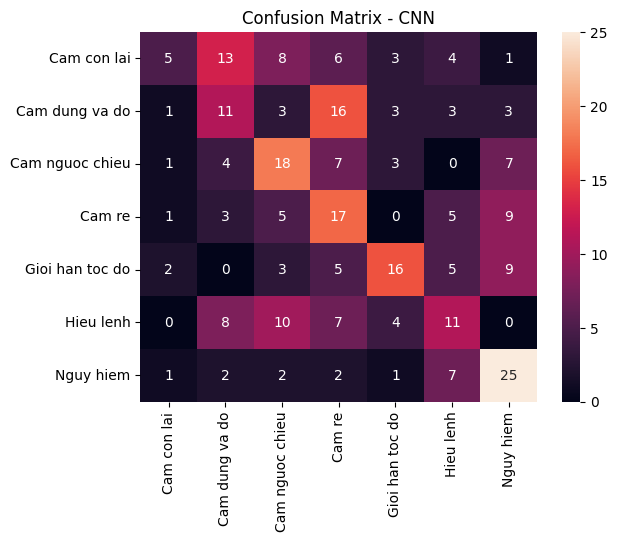

   - YOLOv8: Xem metrics (mAP) trong log huấn luyện


In [ ]:
# --- STEP 7: DATA EVALUATION ---
# CNN
test_gen = custom_generator("test")
y_test_pred_all, y_test_true_all = [], []
for step in range(test_steps):
    try:
        X_batch, y_batch = next(test_gen)
        if len(X_batch) > 0:
            y_pred_batch = cnn_model.predict(X_batch, verbose=0)
            y_test_pred_all.extend(y_pred_batch)
            y_test_true_all.extend(y_batch)
            print(f"Processed batch {step+1}/{test_steps}")
        else:
            print(f"Empty batch at step {step+1}")
    except Exception as e:
        print(f"Error in test generator at step {step+1}: {e}")
        break

if len(y_test_pred_all) > 0:
    y_test_pred_all = np.array(y_test_pred_all)
    y_test_true_all = np.array(y_test_true_all)
    y_test_pred_labels = np.argmax(y_test_pred_all, axis=1)
    y_test_true_labels = np.argmax(y_test_true_all, axis=1)
    print("\n✅ Step 7: Data Evaluation - CNN")
    print(classification_report(y_test_true_labels, y_test_pred_labels, target_names=classes))
    cm = confusion_matrix(y_test_true_labels, y_test_pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix - CNN")
    plt.show()
else:
    print("No valid test data collected for evaluation")

# YOLOv8
print("   - YOLOv8: Xem metrics (mAP) trong log huấn luyện")

In [ ]:
# --- STEP 8: HYPER-PARAMETER TUNING ---
# CNN
try:
    cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    cnn_history_tuned = cnn_model.fit(
        custom_generator("train"),
        steps_per_epoch=train_steps,
        epochs=5,
        validation_data=custom_generator("valid"),
        validation_steps=valid_steps,
        verbose=1
    )
    print("✅ CNN tuning completed successfully")
except Exception as e:
    print(f"Error during CNN tuning: {e}")

# YOLOv8
try:
    yolo_model.train(data=yaml_path, epochs=10, imgsz=64, batch=16, lr0=0.001)
    print("✅ YOLOv8 tuning completed successfully")
except Exception as e:
    print(f"Error during YOLOv8 tuning: {e}")

Generated batch for train: (14, 32, 32, 3), (14, 7)
Generated batch for train: (14, 32, 32, 3), (14, 7)
Epoch 1/5
  1/400 ━━━━━━━━━━━━━━━━━━━━ 11:37 2s/step - accuracy: 0.2143 - loss: 1.6333Generated batch for train: (14, 32, 32, 3), (14, 7)
  3/400 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.2460 - loss: 1.6470Generated batch for train: (14, 32, 32, 3), (14, 7)
  4/400 ━━━━━━━━━━━━━━━━━━━━ 59s 150ms/step - accuracy: 0.2872 - loss: 1.5954Generated batch for train: (14, 32, 32, 3), (14, 7)
  5/400 ━━━━━━━━━━━━━━━━━━━━ 2:58:41 27s/step - accuracy: 0.3069 - loss: 1.5708Generated batch for train: (14, 32, 32, 3), (14, 7)
  6/400 ━━━━━━━━━━━━━━━━━━━━ 2:22:54 22s/step - accuracy: 0.3212 - loss: 1.5530Generated batch for train: (14, 32, 32, 3), (14, 7)
  7/400 ━━━━━━━━━━━━━━━━━━━━ 1:58:59 18s/step - accuracy: 0.3264 - loss: 1.5469Generated batch for train: (14, 32, 32, 3), (14, 7)
  8/400 ━━━━━━━━━━━━━━━━━━━━ 1:41:56 16s/step - accuracy: 0.3324 - loss: 1.5397Generated batch for train: (

train: Scanning /content/drive/MyDrive/DeepLearning/dataset/train/labels.cache... 6390 images, 341 backgrounds, 0 corrupt: 100%|██████████| 6390/6390 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10006_png.rf.a1568bdb43caabdbd8279fb7bb6b59fb.jpg: 4 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10006_png.rf.f59b9ff2f1583e898ba7526159315614.jpg: 3 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10030_png.rf.8381eee64ab8e23a0116479b651cb033.jpg: 4 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10032_png.rf.4541af23fa433ba81c4a400116f36527.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10032_png.rf.67a111d9ebf850bf52563521e99084a4.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10035_png.rf.37b6690170001d7b5cb2895c6c9089d4.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/train/images/10035_p


val: Scanning /content/drive/MyDrive/DeepLearning/dataset/valid/labels.cache... 433 images, 23 backgrounds, 0 corrupt: 100%|██████████| 433/433 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/valid/images/10049_png.rf.d1526b4ec0cfb03ec60a9f84f13206b7.jpg: 5 duplicate labels removed
val: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/valid/images/10173_png.rf.01a13f0fb3ceb86349529378fa633889.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/valid/images/10722_png.rf.8e4a3a7c0e79d466879f41b648f7f0ae.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/valid/images/11051_png.rf.351d2a7687223352d3d3e0ee4da125b4.jpg: 2 duplicate labels removed
val: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/valid/images/11063_png.rf.1eedfe92171e67e7ea64a3e51097a3c8.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/valid/images/11489_png.rf.373618342998530ab4fb41af8b2df78a.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/drive/MyDrive/DeepLearning/dataset/valid/images/11591_png.rf.1570e012

...

      10/10         0G       1.48      1.336     0.4141          1         64: 100%|██████████| 400/400 [03:18<00:00,  2.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:08<00:00,  1.62it/s]

                   all        433        884      0.455    0.00344    0.00209   0.000684



10 epochs completed in 0.610 hours.
Optimizer stripped from runs/detect/train42/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train42/weights/best.pt, 6.2MB

Validating runs/detect/train42/weights/best.pt...
Ultralytics 8.3.102 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:09<00:00,  1.44it/s]


                   all        433        884    0.00293     0.0177    0.00342   0.000793
           Cam con lai         85        135    0.00198    0.00741    0.00137   0.000137
        Cam dung va do        122        171    0.00613     0.0234     0.0109    0.00281
       Cam nguoc chieu         71         95          0          0          0          0
                Cam re         35         45    0.00567     0.0667    0.00708    0.00148
       Gioi han toc do         28         61    0.00264     0.0164    0.00135   0.000271
             Hieu lenh         60         72          0          0          0          0
             Nguy hiem        190        305    0.00409    0.00984    0.00329   0.000856
Speed: 0.0ms preprocess, 7.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/train42
✅ YOLOv8 tuning completed successfully


In [ ]:
# --- STEP 9: BUILD THE PIPELINE ---
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    return np.expand_dims(img, axis=0)

cnn_model.save('/content/drive/MyDrive/DeepLearning/traffic_sign_cnn_best.h5')
yolo_model.save('/content/drive/MyDrive/DeepLearning/traffic_sign_yolov8_best.pt')


✅ Step 10: Conclusion
   - CNN: Phân loại trên toàn bộ tập train với generator cân bằng.
   - YOLOv8: Phát hiện và gắn nhãn trên toàn bộ tập train.
   - Hạn chế: Chạy trên CPU, thời gian lâu hơn.
   - Hướng phát triển: Dùng GPU mạnh hơn nếu cần tốc độ.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

image 1/1 /content/drive/MyDrive/DeepLearning/dataset/test/images/6115_png.rf.ff64bc67a1458f5cbf11fa3dad4a58d4.jpg: 64x64 (no detections), 15.0ms
Speed: 0.9ms preprocess, 15.0ms inference, 0.6ms postprocess per image at shape (1, 3, 64, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

image 1/1 /content/drive/MyDrive/DeepLearning/dataset/test/images/5517_png.rf.db2d495a57008f0acde4b6c5b29a4fb8.jpg: 64x64 (no detections), 10.5ms
Speed: 0.6ms preprocess, 10.5ms inference, 0.7ms postprocess per image at shape (1, 3, 64, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

image 1/1 /content/drive/MyDrive/DeepLearning/dataset/test/images/6268_png.rf.09a90dddfeadab5e5ea238e12fd0ec25.jpg: 64x64 (no detections), 10.4ms
S

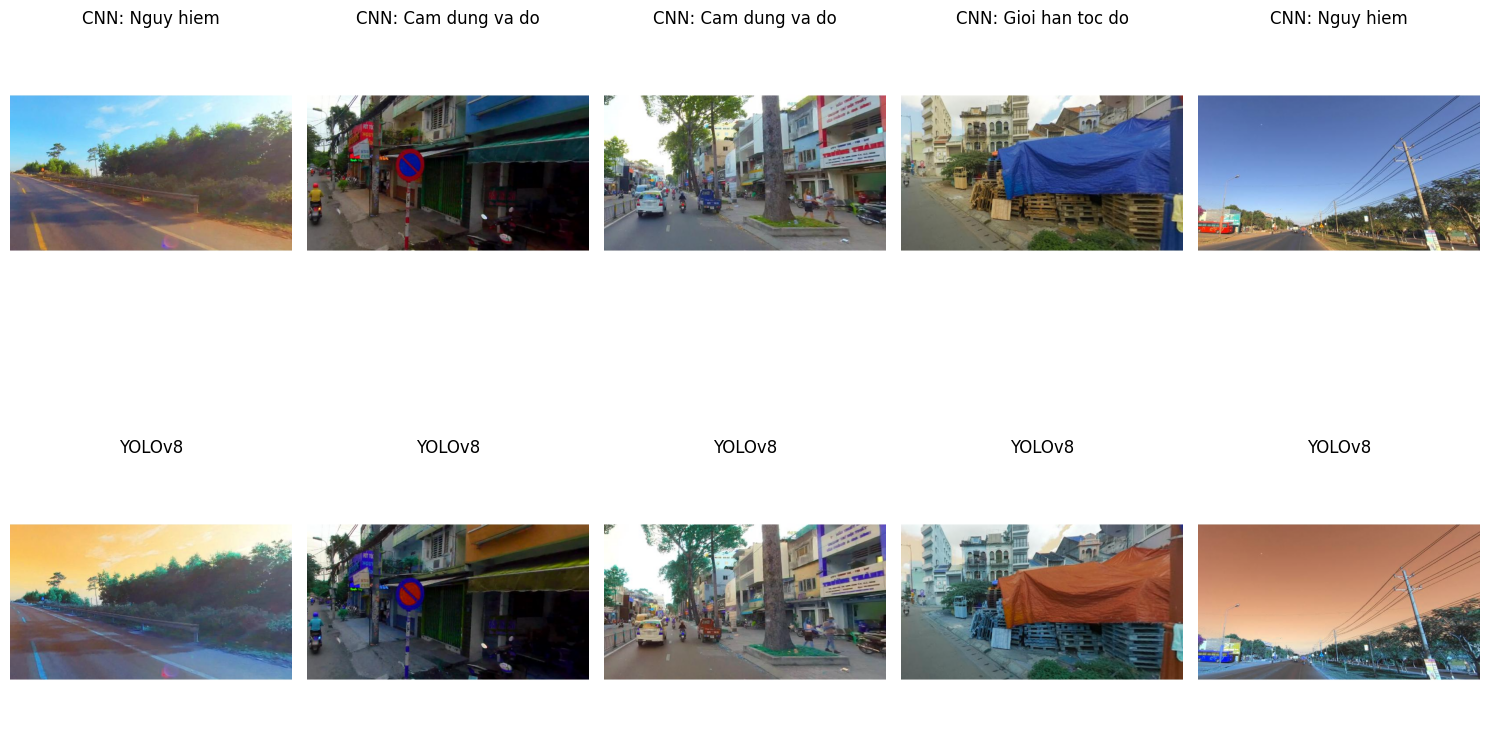

In [ ]:
# --- STEP 10: CONCLUSION ---
print("\n✅ Step 10: Conclusion")
print("   - CNN: Phân loại trên toàn bộ tập train với generator cân bằng.")
print("   - YOLOv8: Phát hiện và gắn nhãn trên toàn bộ tập train.")
print("   - Hạn chế: Chạy trên CPU, thời gian lâu hơn.")
print("   - Hướng phát triển: Dùng GPU mạnh hơn nếu cần tốc độ.")

# Hiển thị kết quả mẫu
test_img_dir = os.path.join(dataset_path, "test", "images")
test_images = os.listdir(test_img_dir)
random_indices = np.random.randint(0, len(test_images), 5)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    img_path = os.path.join(test_img_dir, test_images[idx])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # CNN prediction
    cnn_input = preprocess_image(img_path)
    cnn_pred = cnn_model.predict(cnn_input)
    cnn_label = classes[np.argmax(cnn_pred)]

    # YOLOv8 prediction
    yolo_results = yolo_model.predict(img_path, conf=0.25, iou=0.45)
    yolo_img = yolo_results[0].plot(labels=True, boxes=True)

    plt.subplot(2, 5, i+1)
    plt.imshow(img_rgb)
    plt.title(f"CNN: {cnn_label}")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(yolo_img)
    plt.title("YOLOv8")
    plt.axis('off')

plt.tight_layout()
plt.show()